In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [98]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print(df.shape)
df.head()

(2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Dataset Overview

In [99]:
print("Shape of dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
df.info()

Shape of dataset: (2640, 12)

Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   floa

## Missing Values

In [100]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

No missing values were found in the dataset.

## Duplicate Value Analysis

Before proceeding with exploratory data analysis, it is important to identify duplicate records in the dataset. Duplicate rows can negatively impact model performance and lead to misleading insights.

In [101]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print("Removing duplicate rows...")
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate records found.")

Number of duplicate rows: 0
No duplicate records found.


## Numerical Summary

In [102]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of variables, identify trends, detect patterns, and uncover relationships between different features in the Tesla deliveries dataset.

## Correlation Analysis

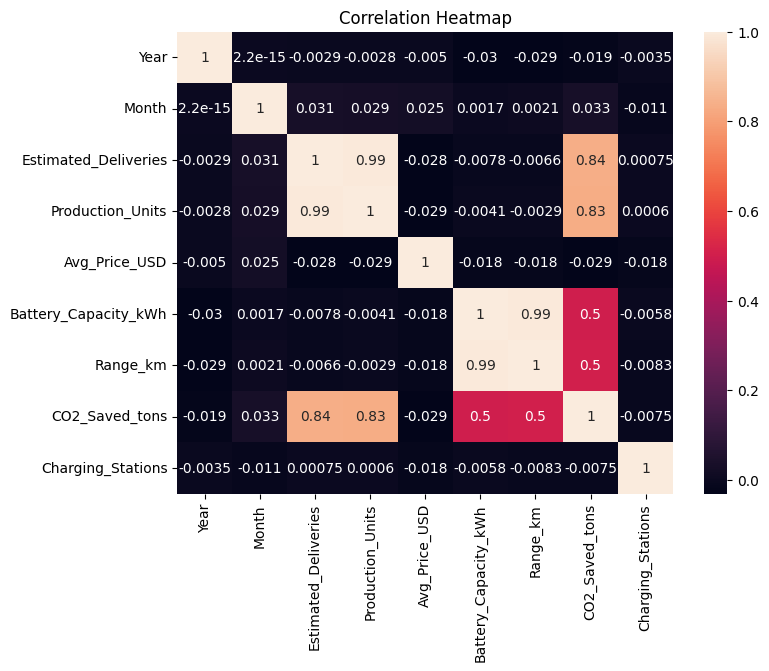

In [103]:
num_cols = df.select_dtypes(include="number")

plt.figure(figsize=(8,6))
sns.heatmap(num_cols.corr(), annot=True)

plt.title("Correlation Heatmap")
plt.show()

### Observation

The correlation heatmap shows the relationship between numerical features in the dataset. Estimated Deliveries has a very strong positive correlation with Production Units (0.99), indicating that higher production generally leads to higher deliveries. CO2 Saved also shows a strong positive relationship with both deliveries and production. Battery Capacity and Range are highly correlated (0.99), which is expected since larger batteries typically provide a longer driving range.

Overall, Production Units and CO2 Saved appear to be the most influential factors related to Tesla deliveries in this dataset.

## Deliveries by Region

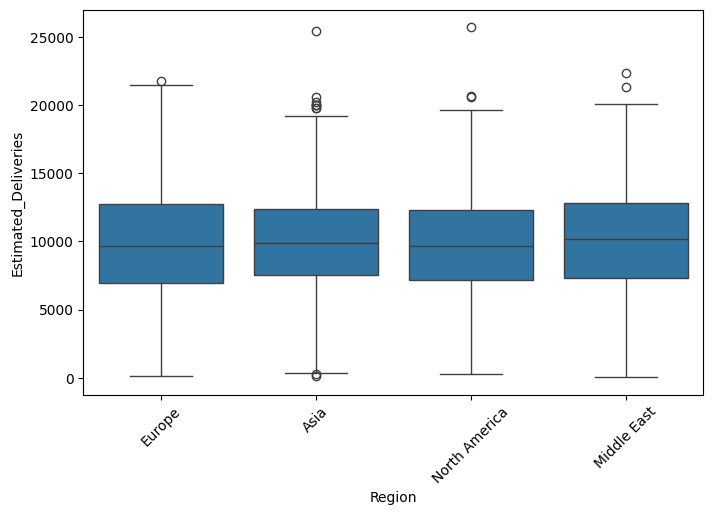

In [104]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Region",
    y="Estimated_Deliveries",
    data=df
)

plt.xticks(rotation=45)
plt.show()

## Deliveries by Tesla Model

This visualization shows the estimated deliveries for different Tesla vehicle models. It helps identify which models contribute the most to overall deliveries.

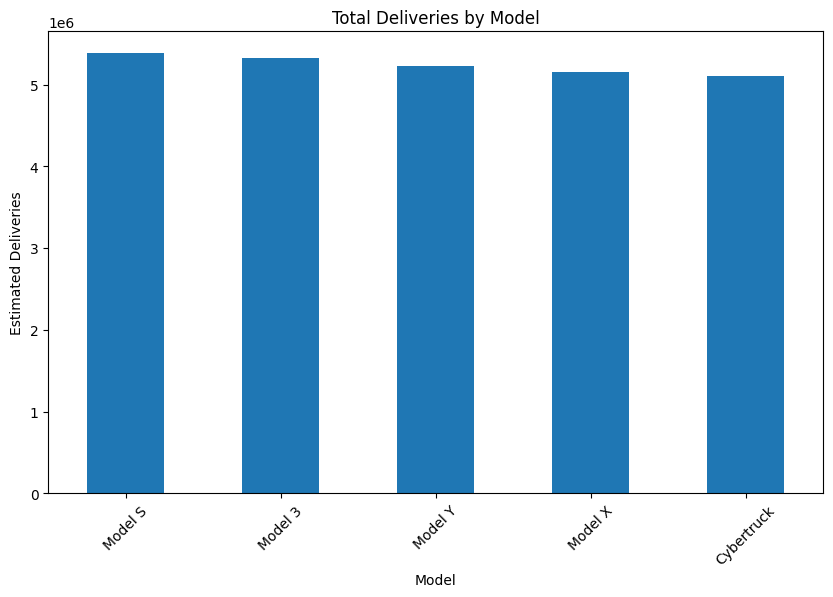

In [105]:
plt.figure(figsize=(10,6))

model_delivery = (
    df.groupby('Model')['Estimated_Deliveries']
      .sum()
      .sort_values(ascending=False)
)

model_delivery.plot(kind='bar')

plt.title("Total Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")
plt.xticks(rotation=45)

plt.show()

## Deliveries by Tesla Model

The bar chart shows the total estimated deliveries for different Tesla models. Model S recorded the highest deliveries, followed closely by Model 3 and Model Y. Model X and Cybertruck also contributed significantly, although with slightly lower delivery counts. Overall, the delivery figures are fairly balanced across models, indicating a diversified product portfolio.

## Production Units vs Estimated Deliveries

This scatter plot shows the relationship between production units and estimated deliveries. A positive trend would indicate that higher production generally results in higher vehicle deliveries.

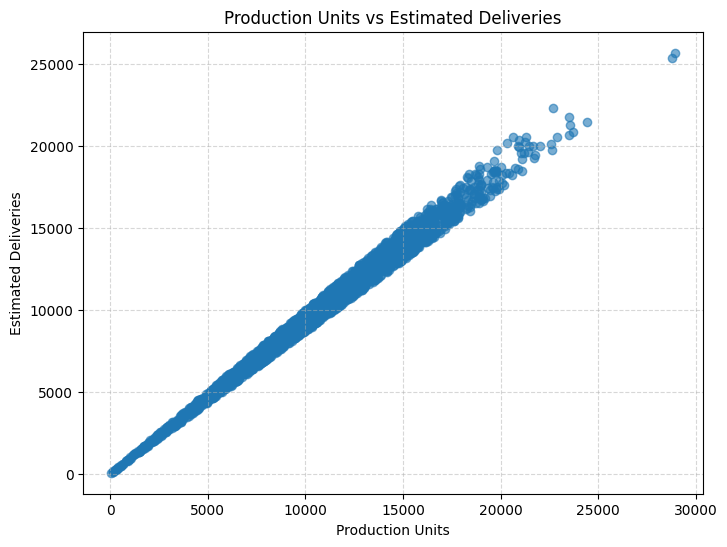

In [106]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Production_Units'],
    df['Estimated_Deliveries'],
    alpha=0.6
)

plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Observation

The scatter plot shows a strong positive relationship between Production Units and Estimated Deliveries. As production increases, deliveries also tend to increase. This observation is consistent with the correlation analysis, where these two variables showed a very high positive correlation.

## Feature Engineering

## Data Preprocessing

Machine learning models require numerical input data. Therefore, the categorical features in the dataset are converted into numerical values using Label Encoding. This allows the models to process categorical information while preserving the distinct categories present in each feature.

In [107]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df_model["Region"] = le_region.fit_transform(df_model["Region"])
df_model["Model"] = le_model.fit_transform(df_model["Model"])
df_model["Source_Type"] = le_source.fit_transform(df_model["Source_Type"])

df_model.head()
df["Region"] = le_region.fit_transform(df["Region"])
df["Model"] = le_model.fit_transform(df["Model"])
df["Source_Type"] = le_source.fit_transform(df["Source_Type"])

print(df.dtypes)

Year                      int64
Month                     int64
Region                    int64
Model                     int64
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type               int64
Charging_Stations         int64
dtype: object


### Observation

The categorical columns **Region**, **Model**, and **Source_Type** have been successfully transformed into numerical form. The dataset is now ready for feature engineering and model training.

### Rolling Mean Feature

A 3-period rolling mean is created using Estimated Deliveries. This feature helps smooth short-term fluctuations and captures the overall delivery trend.

In [108]:
# Create 3-period rolling mean feature

df["Rolling_Mean_3"] = (
    df["Estimated_Deliveries"]
    .rolling(window=3)
    .mean()
)

df["Rolling_Mean_3"] = (
    df["Rolling_Mean_3"]
    .fillna(df["Rolling_Mean_3"].mean())
)

df[["Estimated_Deliveries", "Rolling_Mean_3"]].head()

,Estimated_Deliveries,Rolling_Mean_3
0,17646,9923.677407
1,3797,9923.677407
2,8411,9951.333333
3,6555,6254.333333
4,12374,9113.333333


### Lag Feature

A lag feature is created using the previous delivery value. This provides historical information that can help the model identify delivery patterns over time.

In [109]:
# Create lag feature

df["Deliveries_Lag1"] = (
    df["Estimated_Deliveries"]
    .shift(1)
)

df["Deliveries_Lag1"] = (
    df["Deliveries_Lag1"]
    .fillna(df["Deliveries_Lag1"].mean())
)

df[["Estimated_Deliveries", "Deliveries_Lag1"]].head()

,Estimated_Deliveries,Deliveries_Lag1
0,17646,9924.959454
1,3797,17646.000000
2,8411,3797.000000
3,6555,8411.000000
4,12374,6555.000000


### Observation

The newly created Rolling Mean and Lag features capture historical delivery information and short-term trends. These engineered features may improve the model's ability to predict future Tesla deliveries.

## Preparing Data for Regression

In [110]:
X = df_model.drop("Estimated_Deliveries", axis=1)
y = df_model["Estimated_Deliveries"]

print(X.shape)
print(y.shape)

(2640, 11)
(2640,)


## Train-Test Split

Since this dataset contains time-related information, a chronological split is used instead of a random split. The first 80% of the observations are used for training and the remaining 20% are used for testing. This approach helps simulate real-world forecasting scenarios where future values are predicted using past data.

## Feature Selection

The target variable for this analysis is Estimated Deliveries. All remaining features are used as input variables for model training and prediction.

In [111]:
# Define features and target

X = df.drop("Estimated_Deliveries", axis=1)
y = df["Estimated_Deliveries"]

print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (2640, 13)
Target Variable Shape: (2640,)


In [112]:
# Chronological 80-20 split

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (2112, 13)
Testing Set Shape: (528, 13)


## Linear Regression

In [113]:
print(df.dtypes)
print(X_train.dtypes)

Year                      int64
Month                     int64
Region                    int64
Model                     int64
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type               int64
Charging_Stations         int64
Rolling_Mean_3          float64
Deliveries_Lag1         float64
dtype: object
Year                      int64
Month                     int64
Region                    int64
Model                     int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type               int64
Charging_Stations         int64
Rolling_Mean_3          float64
Deliveries_Lag1         float64
dtype: object


In [114]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [115]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression MAE :", lr_mae)
print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R²  :", lr_r2)

Linear Regression MAE : 310.3345215398841
Linear Regression RMSE: 375.56466645344767
Linear Regression R²  : 0.9908058721380986


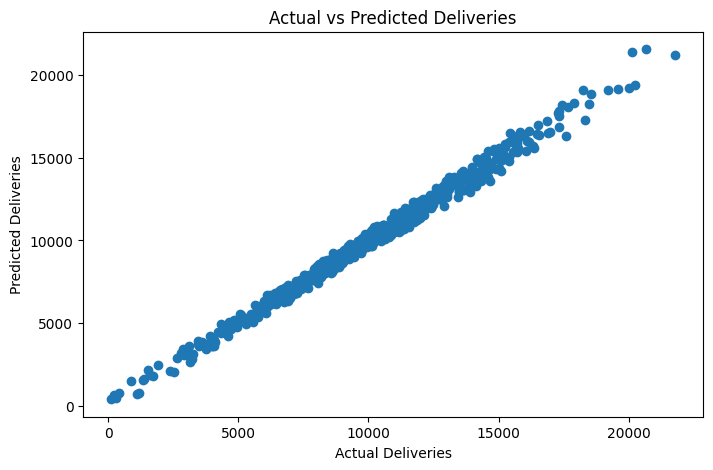

In [116]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted Deliveries")

plt.show()

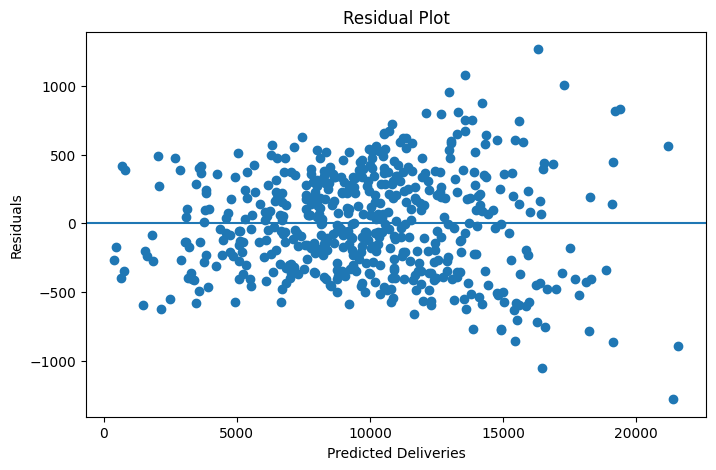

In [117]:
residuals = y_test - lr_pred

plt.figure(figsize=(8,5))

plt.scatter(lr_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Deliveries")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [118]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
3,Model,3.355704
8,CO2_Saved_tons,2.147247
1,Month,0.835118
4,Production_Units,0.760049
11,Rolling_Mean_3,0.032820
10,Charging_Stations,0.000350
5,Avg_Price_USD,0.000137
12,Deliveries_Lag1,-0.011498
6,Battery_Capacity_kWh,-0.578050
0,Year,-0.972949


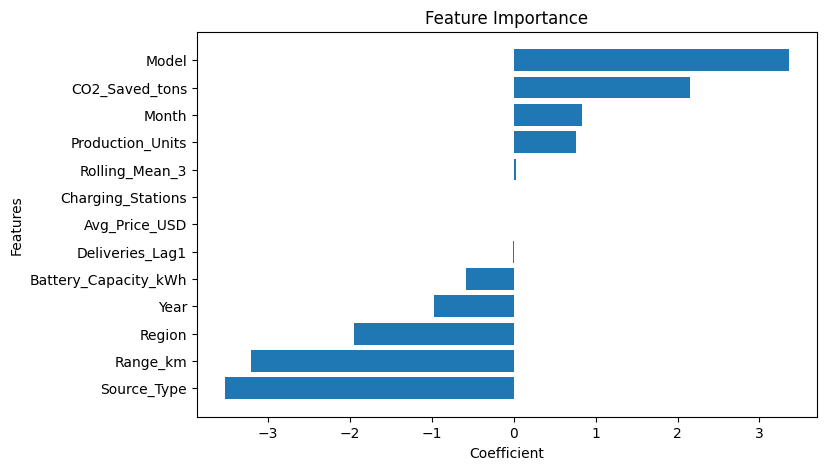

In [119]:
coef_df = coefficients.sort_values(by="Coefficient")

plt.figure(figsize=(8,5))

plt.barh(coef_df["Feature"], coef_df["Coefficient"])

plt.title("Feature Importance")
plt.xlabel("Coefficient")
plt.ylabel("Features")

plt.show()

## Cross Validation

To evaluate the stability and generalization capability of the Linear Regression model, 5-Fold Cross Validation is performed. The dataset is divided into five folds, and the model is trained and validated multiple times using different subsets of the data.

In [120]:
print(type(lr))

<class 'sklearn.linear_model._base.LinearRegression'>


In [121]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    lr,
    X,
    y,
    cv=cv,
    scoring='r2'
)

print("Cross Validation Scores:", cv_scores)
print("Average R² Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores: [0.9902379  0.99086768 0.99074207 0.9899367  0.99009504]
Average R² Score: 0.9903758760823388
Standard Deviation: 0.0003651703161235518


# Hyperparameter Tuning using Random Forest Regressor

In [122]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'n_estimators': 100}
Best CV Score: 0.9871204711144875


In [123]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': None, 'n_estimators': 100}
0.9871204711144875


In [124]:
best_rf = grid_search.best_estimator_

rf_pred = best_rf.predict(X_test)

In [125]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

MAE : 301.7189583333333
RMSE: 384.47494711870604
R²  : 0.9903644351717987


### Observation

GridSearchCV was used to identify the optimal hyperparameters for the Random Forest Regressor. The best-performing model used 100 estimators with no maximum depth restriction. The cross-validation score indicates strong predictive performance and good generalization capability.

## Feature Importance Analysis

Feature importance helps identify which variables contribute the most to predicting Tesla deliveries.

In [126]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,Production_Units,0.990149
8,CO2_Saved_tons,0.002130
7,Range_km,0.001291
5,Avg_Price_USD,0.001078
10,Charging_Stations,0.000973
11,Rolling_Mean_3,0.000922
12,Deliveries_Lag1,0.000893
0,Year,0.000774
1,Month,0.000676
3,Model,0.000383


### Observation

The feature importance analysis highlights the variables that contribute the most to delivery prediction. Features with higher importance scores have a greater influence on the model's predictions and provide insights into the key factors affecting Tesla deliveries.

## Model Comparison

The performance of the implemented models is compared using evaluation metrics to identify the most suitable approach for predicting Tesla deliveries.

In [127]:
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [lr_r2, rf_r2],
    "RMSE": [lr_rmse, rf_rmse],
    "MAE": [lr_mae, rf_mae]
})

comparison_df

,Model,R2 Score,RMSE,MAE
0,Linear Regression,0.990806,375.564666,310.334522
1,Random Forest,0.990364,384.474947,301.718958


### Observation

Both models achieved excellent predictive performance with R² scores above 0.99. Linear Regression achieved a slightly higher R² score and lower RMSE, while Random Forest produced a slightly lower MAE. Overall, both models performed well on the Tesla delivery dataset, with Linear Regression showing a marginal advantage in overall prediction accuracy.

# Time Series Forecasting

In [128]:
ts_data = df.groupby(["Year", "Month"])["Estimated_Deliveries"].sum().reset_index()

ts_data["Date"] = pd.to_datetime(
    ts_data["Year"].astype(str) + "-" +
    ts_data["Month"].astype(str)
)

ts_data = ts_data.sort_values("Date")

ts_data.head()

,Year,Month,Estimated_Deliveries,Date
0,2015,1,183180,2015-01-01
1,2015,2,165053,2015-02-01
2,2015,3,184567,2015-03-01
3,2015,4,225623,2015-04-01
4,2015,5,184264,2015-05-01


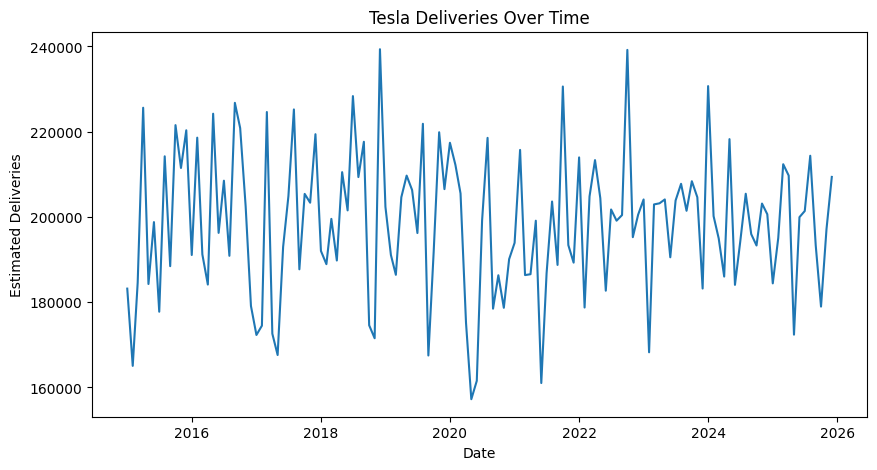

In [129]:
plt.figure(figsize=(10,5))

plt.plot(
    ts_data["Date"],
    ts_data["Estimated_Deliveries"]
)

plt.title("Tesla Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.show()

In [130]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_ts = ExponentialSmoothing(
    ts_data["Estimated_Deliveries"],
    trend="add"
)

fit_model = model_ts.fit()

forecast = fit_model.forecast(12)

print(forecast)

132    199248.199014
133    199353.366605
134    199458.534195
135    199563.701785
136    199668.869376
137    199774.036966
138    199879.204557
139    199984.372147
140    200089.539737
141    200194.707328
142    200299.874918
143    200405.042508
dtype: float64


## Augmented Dickey-Fuller (ADF) Test

The Augmented Dickey-Fuller (ADF) test is used to check whether the time series data is stationary. A stationary series has constant statistical properties over time, which is important for many forecasting techniques.

- **Null Hypothesis (H₀):** The time series is non-stationary.
- **Alternative Hypothesis (H₁):** The time series is stationary.

A p-value less than 0.05 indicates that the null hypothesis can be rejected, suggesting that the series is stationary.

In [131]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df["Estimated_Deliveries"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

if adf_result[1] < 0.05:
    print("\nConclusion: The time series is stationary.")
else:
    print("\nConclusion: The time series is non-stationary.")

ADF Statistic: -53.82661259715622
p-value: 0.0

Critical Values:
1%: -3.432830360798943
5%: -2.8626358355986774
10%: -2.5673533514279425

Conclusion: The time series is stationary.


### Observation

The Augmented Dickey-Fuller (ADF) test produced an ADF statistic of -53.83 and a p-value of 0.0. Since the p-value is less than 0.05, the null hypothesis of non-stationarity is rejected. This indicates that the Tesla deliveries time series is stationary and suitable for time-series analysis and forecasting. The ADF statistic is also significantly lower than the critical values at the 1%, 5%, and 10% significance levels, further confirming stationarity.

## Forecasted Delivery Values

The following table shows the forecasted Tesla delivery values for the next 12 periods generated using the Exponential Smoothing model.

In [132]:
forecast_df = pd.DataFrame({
    "Forecasted_Deliveries": forecast
})

forecast_df

,Forecasted_Deliveries
132,199248.199014
133,199353.366605
134,199458.534195
135,199563.701785
136,199668.869376
137,199774.036966
138,199879.204557
139,199984.372147
140,200089.539737
141,200194.707328


### Observation

The forecasted values provide an estimate of future Tesla deliveries based on historical trends. These predictions can help understand expected delivery patterns and support future planning and analysis.

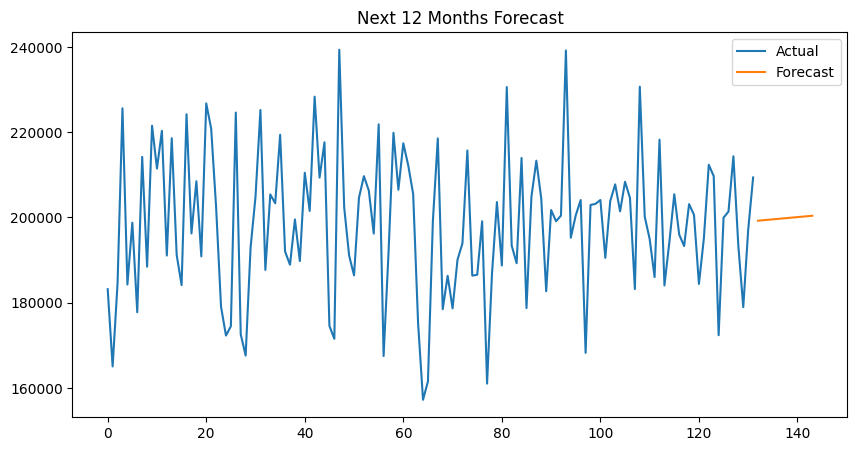

In [133]:
plt.figure(figsize=(10,5))

plt.plot(
    ts_data["Estimated_Deliveries"],
    label="Actual"
)

plt.plot(
    range(len(ts_data),
          len(ts_data)+12),
    forecast,
    label="Forecast"
)

plt.title("Next 12 Months Forecast")
plt.legend()

plt.show()

# Conclusion

In this project, Tesla vehicle delivery data was analyzed using exploratory data analysis, machine learning, and time-series forecasting techniques.

The dataset was preprocessed by encoding categorical variables and creating additional features such as lag and rolling mean values. Linear Regression and Random Forest Regression models were trained and evaluated using MAE, RMSE, and R² metrics. Cross-validation and hyperparameter tuning were performed to improve model reliability and performance.

Both models achieved strong predictive performance, with Linear Regression slightly outperforming Random Forest in terms of R² score. Feature importance analysis helped identify the variables that contribute most to delivery prediction.

Time-series forecasting was performed using Exponential Smoothing, and the ADF test confirmed that the delivery series is stationary. The generated forecasts provide useful insights into future delivery trends.

Overall, the project demonstrates the effectiveness of data analysis, machine learning, and forecasting techniques for understanding and predicting Tesla vehicle deliveries.